# Model Comparison V3 - Stock-Aware Sentiment + Binary vs 3-class + isPresident

Nieuwe features tov V2:
- **LLM-based tweet -> stock impact scoring** (sentence-transformer met TF-IDF fallback)
- **Stock-aware sentiment aggregatie** ipv market-wide
- **isPresident feature**: 1 als datum tijdens Trump's ambtstermijn valt
- **Binary vs 3-class vergelijking** voor alle modellen
- **trained_models tracking** voor save-best-per-stocktype aan het eind

## 1. Setup

In [1]:
import os, sys, json, warnings, time, re
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5); sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "comparison" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS = PROJECT_ROOT / "model" / "comparison" / "artifacts_v3_v2"
PER_STOCK = ARTIFACTS / "per_stock"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
PER_STOCK.mkdir(parents=True, exist_ok=True)
print("Artifacts:", ARTIFACTS)

Artifacts: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v3_v2


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, mean_absolute_error, brier_score_loss, confusion_matrix,
)
from sklearn.dummy import DummyClassifier

def _try_import(name):
    try: return __import__(name), True
    except ImportError: return None, False
xgb, HAS_XGB = _try_import("xgboost")
lgb, HAS_LGB = _try_import("lightgbm")

# Torch sanity check (Adam optimizer maken — vangt torch._dynamo issues)
HAS_TORCH = False; torch = None
try:
    import torch as _t, torch.nn as _nn
    _p = _nn.Parameter(_t.zeros(1)); _opt = _t.optim.Adam([_p], lr=1e-3); _opt.step()
    torch = _t; HAS_TORCH = True
except Exception as _e:
    print(f"PyTorch niet werkbaar: {type(_e).__name__}: {str(_e)[:120]}")
    print("Fix: pip uninstall torch -y && pip install --no-cache-dir 'torch>=2.3,<2.6'")

print(f"XGBoost:{'OK' if HAS_XGB else 'X'}\nLightGBM:{'OK' if HAS_LGB else 'X'}\nPyTorch:{'OK' if HAS_TORCH else 'X'}")

XGBoost:OK LightGBM:OK PyTorch:OK


In [ ]:
# VADER
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    HAS_VADER = True; vader = SentimentIntensityAnalyzer()
except ImportError:
    HAS_VADER = False; print("pip install vaderSentiment")

# Sentence-transformer (broad except: torch issues geven AttributeError, geen ImportError)
HAS_ST = False
try:
    from sentence_transformers import SentenceTransformer
    HAS_ST = True
except Exception as _e:
    print(f"sentence-transformers off ({type(_e).__name__}: {str(_e)[:80]})")
    print("=> TF-IDF fallback wordt gebruikt voor impact scoring")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
print(f"VADER:{'OK' if HAS_VADER else 'X'}\nST:{'OK' if HAS_ST else 'OFF (TF-IDF)'}")

VADER:OK  ST:OK


## 2. Database

In [4]:
from database.connectie.connectie import get_engine, getData
engine = get_engine()

def get_or_die(query, name):
    df = getData(engine=engine, query=query)
    if df is None: raise RuntimeError(f"Query '{name}' faalde")
    return df

## 3. Market data

In [5]:
SQL_MARKET = '''
SELECT m.DateKey, d.FullDateAlternateKey AS [Date],
       LTRIM(RTRIM(m.StockKey)) AS StockKey,
       COALESCE(NULLIF(LTRIM(RTRIM(s.StockName)),''), LTRIM(RTRIM(m.StockKey))) AS StockName,
       s.[Type] AS StockType,
       CAST(m.[Open] AS FLOAT) AS [Open], CAST(m.High AS FLOAT) AS High,
       CAST(m.Low AS FLOAT) AS Low, CAST(m.[Close] AS FLOAT) AS [Close],
       CAST(m.Volume AS FLOAT) AS Volume,
       CAST(e.USD AS FLOAT) AS USD, CAST(e.OIL AS FLOAT) AS OIL,
       CAST(e.VIX AS FLOAT) AS VIX, CAST(e.YieldSpread AS FLOAT) AS YieldSpread,
       CAST(e.InfExpectation AS FLOAT) AS InfExpectation,
       CAST(e.FinStress AS FLOAT) AS FinStress,
       CAST(e.FedFundsRate AS FLOAT) AS FedFundsRate,
       CAST(e.FedBalanceSheet AS FLOAT) AS FedBalanceSheet,
       CAST(e.CPI AS FLOAT) AS CPI, CAST(e.PPI AS FLOAT) AS PPI,
       CAST(e.Consumer_Confidence AS FLOAT) AS Consumer_Confidence
FROM FactMarketData m
JOIN DimDate d ON d.DateKey = m.DateKey
LEFT JOIN DimStock s ON LTRIM(RTRIM(s.StockKey)) = LTRIM(RTRIM(m.StockKey))
LEFT JOIN FactEcon e ON e.DateKey = m.DateKey
WHERE m.StockKey IS NOT NULL AND LEN(LTRIM(RTRIM(m.StockKey))) > 0
ORDER BY m.StockKey, d.FullDateAlternateKey
'''
market_df = get_or_die(SQL_MARKET, "market")
market_df["Date"] = pd.to_datetime(market_df["Date"])
market_df["stock_id"] = market_df["StockName"].fillna(market_df["StockKey"]).astype(str)
print(f"market_df: {len(market_df):,} rijen, {market_df['stock_id'].nunique()} stocks")

market_df: 470,856 rijen, 181 stocks


## 4. Tweets + nieuws ophalen

In [6]:
SQL_TWEETS = '''
SELECT d.FullDateAlternateKey AS [Date], t.[Text],
       COALESCE(CAST(t.influenceScore AS FLOAT), 0) AS influence
FROM DimTwitter t JOIN DimDate d ON d.DateKey = t.DateKey
WHERE t.[Text] IS NOT NULL AND LEN(t.[Text]) > 0
'''
SQL_NEWS = '''
SELECT d.FullDateAlternateKey AS [Date],
       COALESCE(n.Headline,'') + ' ' + COALESCE(n.Abstract,'') AS [Text],
       COALESCE(CAST(n.influenceScore AS FLOAT), 0) AS influence
FROM FactNews n JOIN DimDate d ON d.DateKey = n.DateKey
WHERE (n.Headline IS NOT NULL OR n.Abstract IS NOT NULL)
'''
tweets_df = get_or_die(SQL_TWEETS, "tweets").reset_index(drop=True)
news_df   = get_or_die(SQL_NEWS,   "news").reset_index(drop=True)
tweets_df["Date"] = pd.to_datetime(tweets_df["Date"])
news_df["Date"]   = pd.to_datetime(news_df["Date"])
print(f"tweets: {len(tweets_df):,}  |  news: {len(news_df):,}")

tweets: 56,458  |  news: 253,014


## 5. VADER sentiment scoring

In [7]:
BULLISH = {"rally","surge","beat","upgrade","outperform","bullish","growth","soar","jump","gain","record","strong","profit"}
BEARISH = {"crash","plunge","miss","downgrade","underperform","bearish","decline","fall","drop","loss","weak","warning","lawsuit","investigation","default","bankruptcy"}
TICKER_RE = re.compile(r"\$[A-Z]{1,5}\b")
WORD_RE   = re.compile(r"\b[a-zA-Z']+\b")
EXCL_RE   = re.compile(r"!")

def text_features(t):
    if not isinstance(t, str) or not t:
        return {"v_compound":0,"v_pos":0,"v_neg":0,"v_neu":1,"n_tickers":0,"n_excl":0,"caps_ratio":0,"n_words":0,"n_bull":0,"n_bear":0}
    v = vader.polarity_scores(t) if HAS_VADER else {"compound":0,"pos":0,"neg":0,"neu":1}
    words = WORD_RE.findall(t); n_words = len(words)
    caps = sum(1 for w in words if len(w)>1 and w.isupper())
    caps_ratio = caps/n_words if n_words else 0
    lower = t.lower()
    return {"v_compound":v["compound"],"v_pos":v["pos"],"v_neg":v["neg"],"v_neu":v["neu"],
            "n_tickers":len(TICKER_RE.findall(t)),"n_excl":len(EXCL_RE.findall(t)),
            "caps_ratio":caps_ratio,"n_words":n_words,
            "n_bull":sum(1 for kw in BULLISH if kw in lower),
            "n_bear":sum(1 for kw in BEARISH if kw in lower)}

def score_df(df):
    feats = pd.DataFrame.from_records(df["Text"].map(text_features).tolist(), index=df.index)
    return pd.concat([df, feats], axis=1)

print("Scoring..."); tweets_scored = score_df(tweets_df); news_scored = score_df(news_df)
print(f"Tweets: {len(tweets_scored):,}, News: {len(news_scored):,}")

Scoring...
Tweets: 56,458, News: 253,014


## 6. Tweet -> stock impact scoring (LLM of TF-IDF)

In [8]:
stocks_meta = market_df.groupby("stock_id").first()[["StockKey","StockName","StockType"]].reset_index().fillna("")

def stock_descriptor(row):
    parts = []
    if row["StockName"]: parts.append(str(row["StockName"]))
    if row["StockKey"] and row["StockKey"] != row["StockName"]:
        parts.append(f"ticker symbol {row['StockKey']}")
    if row["StockType"]: parts.append(f"type {row['StockType']}")
    parts.append("stock financial market")
    return " ".join(p.strip() for p in parts if p)

stocks_meta["descriptor"] = stocks_meta.apply(stock_descriptor, axis=1)
n_tweets = len(tweets_df); n_stocks = len(stocks_meta)
print(f"Computing impact: {n_tweets:,} x {n_stocks} = {n_tweets*n_stocks:,} pairs")

impact = None; method = None
if HAS_ST:
    try:
        st_model = SentenceTransformer("all-MiniLM-L6-v2")
        stock_emb = st_model.encode(stocks_meta["descriptor"].tolist(), normalize_embeddings=True, show_progress_bar=False)
        tweet_emb = st_model.encode(tweets_df["Text"].tolist(), normalize_embeddings=True, batch_size=64, show_progress_bar=True)
        impact = np.clip(tweet_emb @ stock_emb.T, 0, 1).astype(np.float32)
        method = "sentence-transformer"
    except Exception as _e:
        print(f"ST faalde, fallback: {type(_e).__name__}")
        HAS_ST = False

if impact is None:
    print("TF-IDF cosine similarity fallback...")
    all_texts = list(tweets_df["Text"].fillna("")) + list(stocks_meta["descriptor"])
    tfidf = TfidfVectorizer(lowercase=True, ngram_range=(1,2), max_features=20_000, min_df=2, stop_words="english").fit(all_texts)
    impact = np.clip(sk_cosine(tfidf.transform(tweets_df["Text"].fillna("")), tfidf.transform(stocks_meta["descriptor"])), 0, 1).astype(np.float32)
    method = "tf-idf"

# Direct ticker mention boost
tweet_lower = tweets_df["Text"].fillna("").str.lower()
for j, row in stocks_meta.iterrows():
    keys = []
    if row["StockKey"]: keys.append(re.escape(str(row["StockKey"]).lower()))
    if row["StockName"]:
        for w in re.findall(r"\b[A-Za-z]{3,}\b", str(row["StockName"])):
            if w.lower() not in {"the","inc","ltd","corp","plc","group","company","stock","etf","index"}:
                keys.append(re.escape(w.lower()))
    if keys:
        pattern = r"(?:^|[^a-z])(" + "|".join(set(keys)) + r")(?:[^a-z]|$)"
        has_mention = tweet_lower.str.contains(pattern, regex=True, na=False).values
        impact[has_mention, j] = np.maximum(impact[has_mention, j], 0.95)

print(f"Method: {method}, impact mean: {impact.mean():.3f}")

Computing impact: 56,458 x 181 = 10,218,898 pairs


Batches: 100%|██████████| 883/883 [06:49<00:00,  2.16it/s]


Method: sentence-transformer, impact mean: 0.041


## 7. Stock-aware sentiment aggregatie + presidential boost

Tweets tijdens Trump's ambtstermijnen krijgen een hogere weegfactor.

In [9]:
# Presidential boost (Trump term 1: 20 jan 2017 - 20 jan 2021, term 2: vanaf 20 jan 2025)
PRESIDENTIAL_BOOST = 2.0
tweets_scored["dnorm"] = tweets_scored["Date"].dt.normalize()
_term1 = (tweets_scored["Date"] >= "2017-01-20") & (tweets_scored["Date"] <= "2021-01-20")
_term2 = tweets_scored["Date"] >= "2025-01-20"
_is_pres_tweet = (_term1 | _term2).astype(float).values
_pres_mult = 1.0 + (PRESIDENTIAL_BOOST - 1.0) * _is_pres_tweet
print(f"Boost x{PRESIDENTIAL_BOOST} op {int(_is_pres_tweet.sum()):,} tweets tijdens presidentschap")

per_stock_records = []
for j, row in stocks_meta.iterrows():
    sid = row["stock_id"]
    w = impact[:, j].astype(np.float64) * _pres_mult
    sub = tweets_scored.copy()
    sub["w"] = w
    sub["w_compound"] = sub["v_compound"] * w
    sub["w_bull"] = sub["n_bull"] * w
    sub["w_bear"] = sub["n_bear"] * w
    g = sub.groupby("dnorm").agg(
        sum_w=("w","sum"), n_items=("w","size"),
        sum_w_compound=("w_compound","sum"),
        sum_w_bull=("w_bull","sum"),
        sum_w_bear=("w_bear","sum"),
        max_w=("w","max"),
        compound_std=("v_compound","std"),
    ).reset_index()
    eps = 1e-6
    g["tw_compound_wmean"] = g["sum_w_compound"] / (g["sum_w"] + eps)
    g["tw_bull_w"] = g["sum_w_bull"]; g["tw_bear_w"] = g["sum_w_bear"]
    g["tw_total_impact"] = g["sum_w"]; g["tw_max_impact"] = g["max_w"]
    g["tw_n_items"] = g["n_items"]; g["tw_compound_std"] = g["compound_std"].fillna(0)
    g["stock_id"] = sid
    per_stock_records.append(g[["dnorm","stock_id","tw_compound_wmean","tw_bull_w","tw_bear_w","tw_total_impact","tw_max_impact","tw_n_items","tw_compound_std"]].rename(columns={"dnorm":"Date"}))
tw_per_stock = pd.concat(per_stock_records, ignore_index=True)

# News market-wide
news_scored["dnorm"] = news_scored["Date"].dt.normalize()
gn = news_scored.groupby("dnorm")
news_daily = pd.DataFrame({
    "news_compound_mean": gn["v_compound"].mean(),
    "news_compound_std":  gn["v_compound"].std().fillna(0),
    "news_n_items":       gn.size(),
    "news_bull_sum":      gn["n_bull"].sum(),
    "news_bear_sum":      gn["n_bear"].sum(),
}).reset_index().rename(columns={"dnorm":"Date"})
print(f"tw_per_stock: {tw_per_stock.shape}, news_daily: {news_daily.shape}")

Boost x2.0 op 31,142 tweets tijdens presidentschap
tw_per_stock: (578114, 9), news_daily: (3767, 6)


## 8. Join + features + isPresident

In [10]:
df = market_df.merge(tw_per_stock, on=["Date","stock_id"], how="left")
df = df.merge(news_daily, on="Date", how="left")
sent_cols = [c for c in df.columns if c.startswith(("tw_","news_"))]
df[sent_cols] = df.sort_values(["stock_id","Date"]).groupby("stock_id")[sent_cols].ffill().fillna(0)

def add_engineered(g):
    g = g.sort_values("Date").copy()
    c = g["Close"]
    g["log_return"] = np.log(c / c.shift(1))
    g["return_5d"]  = c.pct_change(5); g["return_10d"] = c.pct_change(10)
    g["rolling_mean_5"] = c.rolling(5).mean()
    g["rolling_std_5"]  = c.rolling(5).std()
    g["rolling_std_20"] = c.rolling(20).std()
    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    g["rsi_14"] = (100 - 100/(1 + gain/loss.replace(0,np.nan))).fillna(50)
    m20 = c.rolling(20).mean(); s20 = c.rolling(20).std().replace(0,np.nan)
    g["bollinger_pos"] = ((c - m20)/s20).fillna(0)
    v = g["Volume"]
    g["vol_zscore"] = ((v - v.rolling(20).mean()) / v.rolling(20).std().replace(0,np.nan)).fillna(0)
    # isPresident
    d = pd.to_datetime(g["Date"])
    _t1 = (d >= "2017-01-20") & (d <= "2021-01-20")
    _t2 = d >= "2025-01-20"
    g["isPresident"] = (_t1 | _t2).astype(int)
    return g

_out = []
for _sid, _g in df.groupby("stock_id", sort=False):
    _g2 = add_engineered(_g); _g2["stock_id"] = _sid; _out.append(_g2)
df = pd.concat(_out, ignore_index=True)
print(f"df: {df.shape}")

df: (470856, 44)


## 9. Binary en 3-class targets

In [11]:
HORIZON = 1; THRESHOLD_NEUTRAL = 0.005

def add_targets(g):
    g = g.sort_values("Date").copy()
    fut = g["Close"].shift(-HORIZON)
    fut_ret = fut / g["Close"] - 1
    g["y_return"] = fut_ret
    g["target_bin"] = (fut_ret > 0).astype(float)
    cls = np.full(len(g), np.nan)
    cls[fut_ret < -THRESHOLD_NEUTRAL] = 0
    cls[(fut_ret >= -THRESHOLD_NEUTRAL) & (fut_ret <= THRESHOLD_NEUTRAL)] = 1
    cls[fut_ret > THRESHOLD_NEUTRAL] = 2
    g["target_3"] = cls
    g.loc[fut.isna(), ["target_bin","target_3","y_return"]] = np.nan
    return g

_out = []
for _sid, _g in df.groupby("stock_id", sort=False):
    _g2 = add_targets(_g); _g2["stock_id"] = _sid; _out.append(_g2)
df = pd.concat(_out, ignore_index=True).dropna(subset=["target_bin","target_3"]).reset_index(drop=True)
df["target_bin"] = df["target_bin"].astype(int); df["target_3"] = df["target_3"].astype(int)
print(f"Final: {df.shape}, binary balance: {df['target_bin'].mean():.3f}")
print(f"3-class: {df['target_3'].value_counts(normalize=True).round(3).to_dict()}")

Final: (470675, 47), binary balance: 0.519
3-class: {2: 0.351, 1: 0.334, 0: 0.314}


## 10. Tijds-split

In [12]:
dates_sorted = np.sort(df["Date"].unique())
n = len(dates_sorted)
TRAIN_END = pd.Timestamp(dates_sorted[int(n*0.75)-1])
VAL_END   = pd.Timestamp(dates_sorted[int(n*0.90)-1])
train_df = df[df["Date"] <= TRAIN_END].copy()
val_df   = df[(df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END)].copy()
test_df  = df[df["Date"] > VAL_END].copy()
print(f"Train:{len(train_df):,}  Val:{len(val_df):,}  Test:{len(test_df):,}")

Train:351,056  Val:71,427  Test:48,192


## 11. Feature matrices

In [13]:
META_COLS = {"DateKey","Date","StockKey","StockName","StockType","stock_id","target_bin","target_3","y_return"}
PRICE_FEATURES = ["Open","High","Low","Close","Volume","log_return","return_5d","return_10d",
                  "rolling_mean_5","rolling_std_5","rolling_std_20",
                  "rsi_14","bollinger_pos","vol_zscore",
                  "USD","OIL","VIX","YieldSpread","InfExpectation","FinStress",
                  "FedFundsRate","FedBalanceSheet","CPI","PPI","Consumer_Confidence"]
SENT_FEATURES = [c for c in df.columns if c.startswith(("tw_","news_"))]
EXTRA_FEATURES = ["isPresident"]
PRICE_FEATURES = [c for c in PRICE_FEATURES if c in df.columns]
EXTRA_FEATURES = [c for c in EXTRA_FEATURES if c in df.columns]
FEATURE_COLS = PRICE_FEATURES + SENT_FEATURES + EXTRA_FEATURES
print(f"Price:{len(PRICE_FEATURES)} Sent:{len(SENT_FEATURES)} Extra:{len(EXTRA_FEATURES)} Total:{len(FEATURE_COLS)}")

Price:25 Sent:12 Extra:1 Total:38


In [14]:
def with_dummies(d):
    return pd.get_dummies(d.copy(), columns=["stock_id"], prefix="stk", drop_first=False)
train_tab = with_dummies(train_df); val_tab = with_dummies(val_df); test_tab = with_dummies(test_df)
all_cols = sorted(set(train_tab.columns) | set(val_tab.columns) | set(test_tab.columns))
for d in (train_tab, val_tab, test_tab):
    for c in all_cols:
        if c not in d.columns: d[c] = 0
stk_cols = [c for c in train_tab.columns if c.startswith("stk_")]
TAB_FEATURES = FEATURE_COLS + stk_cols

X_tr = np.nan_to_num(train_tab[TAB_FEATURES].astype(float).values)
X_va = np.nan_to_num(val_tab  [TAB_FEATURES].astype(float).values)
X_te = np.nan_to_num(test_tab [TAB_FEATURES].astype(float).values)
y_bin_tr = train_tab["target_bin"].astype(int).values
y_bin_va = val_tab  ["target_bin"].astype(int).values
y_bin_te = test_tab ["target_bin"].astype(int).values
y_3_tr   = train_tab["target_3"].astype(int).values
y_3_va   = val_tab  ["target_3"].astype(int).values
y_3_te   = test_tab ["target_3"].astype(int).values
test_stock_ids = test_df["stock_id"].values
test_dates     = test_df["Date"].values
test_close     = test_df["Close"].values
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr); X_va_s = scaler.transform(X_va); X_te_s = scaler.transform(X_te)
print(f"X_tr: {X_tr.shape}")

X_tr: (351056, 219)


## 12. Evaluate helpers + trained_models tracker

In [15]:
results_bin = []; results_3 = []
predictions_bin = {}; predictions_3 = {}
trained_models = {}   # voor save-best-per-stocktype

def safe_mape(y_true, y_pred, eps=1e-3):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def log_binary(name, y_tr_p, y_va_p, y_te_p, y_te_proba,
               stock_ids=None, dates=None, close=None,
               y_tr_true=None, y_va_true=None, y_te_true=None):
    yt_tr = y_tr_true if y_tr_true is not None else y_bin_tr
    yt_va = y_va_true if y_va_true is not None else y_bin_va
    yt_te = y_te_true if y_te_true is not None else y_bin_te
    rec = {"model": name}
    if y_tr_p is not None: rec["train_acc"] = accuracy_score(yt_tr, y_tr_p)
    if y_va_p is not None:
        rec["val_acc"] = accuracy_score(yt_va, y_va_p)
        rec["val_f1"]  = f1_score(yt_va, y_va_p, zero_division=0)
    rec["test_acc"]  = accuracy_score(yt_te, y_te_p)
    rec["precision"] = precision_score(yt_te, y_te_p, zero_division=0)
    rec["recall"]    = recall_score(yt_te, y_te_p, zero_division=0)
    rec["f1"]        = f1_score(yt_te, y_te_p, zero_division=0)
    if y_te_proba is not None:
        rec["roc_auc"] = roc_auc_score(yt_te, y_te_proba)
        rec["mae"]     = mean_absolute_error(yt_te, y_te_proba)
        rec["mape"]    = safe_mape(yt_te, y_te_proba)
        rec["brier"]   = brier_score_loss(yt_te, y_te_proba)
    results_bin.append(rec)
    msg = "  ".join(f"{k}={v:.3f}" for k,v in rec.items() if isinstance(v,float))
    print(f"  [BIN] {name:25s}  {msg}")
    predictions_bin[name] = {
        "stock_id": stock_ids if stock_ids is not None else test_stock_ids,
        "Date":     dates    if dates    is not None else test_dates,
        "Close":    close    if close    is not None else test_close,
        "y_true": yt_te, "y_pred": y_te_p,
        "y_proba": y_te_proba if y_te_proba is not None else np.full_like(yt_te, 0.5, dtype=float),
    }
    return rec

def log_3class(name, y_tr_p, y_va_p, y_te_p, y_te_proba_mat,
               stock_ids=None, dates=None, close=None,
               y_tr_true=None, y_va_true=None, y_te_true=None):
    yt_tr = y_tr_true if y_tr_true is not None else y_3_tr
    yt_va = y_va_true if y_va_true is not None else y_3_va
    yt_te = y_te_true if y_te_true is not None else y_3_te
    rec = {"model": name}
    if y_tr_p is not None: rec["train_acc"] = accuracy_score(yt_tr, y_tr_p)
    if y_va_p is not None:
        rec["val_acc"]      = accuracy_score(yt_va, y_va_p)
        rec["val_f1_macro"] = f1_score(yt_va, y_va_p, average="macro", zero_division=0)
    rec["test_acc"]        = accuracy_score(yt_te, y_te_p)
    rec["precision_macro"] = precision_score(yt_te, y_te_p, average="macro", zero_division=0)
    rec["recall_macro"]    = recall_score(yt_te, y_te_p, average="macro", zero_division=0)
    rec["f1_macro"]        = f1_score(yt_te, y_te_p, average="macro", zero_division=0)
    rec["f1_weighted"]     = f1_score(yt_te, y_te_p, average="weighted", zero_division=0)
    if y_te_proba_mat is not None and y_te_proba_mat.ndim == 2 and y_te_proba_mat.shape[1] == 3:
        try: rec["roc_auc_ovr"] = roc_auc_score(yt_te, y_te_proba_mat, multi_class="ovr", average="macro", labels=[0,1,2])
        except Exception: rec["roc_auc_ovr"] = float("nan")
        rec["mae_ordinal"] = float(np.mean(np.abs(yt_te.astype(float) - y_te_p.astype(float))))
    results_3.append(rec)
    msg = "  ".join(f"{k}={v:.3f}" for k,v in rec.items() if isinstance(v,float))
    print(f"  [3CL] {name:25s}  {msg}")
    predictions_3[name] = {
        "stock_id": stock_ids if stock_ids is not None else test_stock_ids,
        "Date":     dates    if dates    is not None else test_dates,
        "Close":    close    if close    is not None else test_close,
        "y_true": yt_te, "y_pred": y_te_p,
        "y_proba": y_te_proba_mat,
    }
    return rec

## 13. Binary tabular modellen

In [16]:
print("=== BINARY ===")
dummy_b = DummyClassifier(strategy="most_frequent").fit(X_tr_s, y_bin_tr)
log_binary("Majority class", dummy_b.predict(X_tr_s), dummy_b.predict(X_va_s),
           dummy_b.predict(X_te_s), dummy_b.predict_proba(X_te_s)[:,1])
trained_models["Majority class"] = dummy_b

logreg_b = LogisticRegression(max_iter=2000, C=0.5, class_weight="balanced").fit(X_tr_s, y_bin_tr)
log_binary("Logistic Regression", logreg_b.predict(X_tr_s), logreg_b.predict(X_va_s),
           logreg_b.predict(X_te_s), logreg_b.predict_proba(X_te_s)[:,1])
trained_models["Logistic Regression"] = logreg_b

rf_b = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                              class_weight="balanced", n_jobs=-1, random_state=42).fit(X_tr, y_bin_tr)
log_binary("Random Forest", rf_b.predict(X_tr), rf_b.predict(X_va),
           rf_b.predict(X_te), rf_b.predict_proba(X_te)[:,1])
trained_models["Random Forest"] = rf_b

if HAS_XGB:
    from xgboost import XGBClassifier
    xgb_b = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                          eval_metric="logloss", n_jobs=-1, random_state=42,
                          scale_pos_weight=(y_bin_tr==0).sum()/max((y_bin_tr==1).sum(),1))
    xgb_b.fit(X_tr, y_bin_tr, eval_set=[(X_va, y_bin_va)], verbose=False)
    log_binary("XGBoost", xgb_b.predict(X_tr), xgb_b.predict(X_va),
               xgb_b.predict(X_te), xgb_b.predict_proba(X_te)[:,1])
    trained_models["XGBoost"] = xgb_b

if HAS_LGB:
    from lightgbm import LGBMClassifier
    lgb_b = LGBMClassifier(n_estimators=500, num_leaves=31, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                           n_jobs=-1, random_state=42, verbose=-1, class_weight="balanced")
    lgb_b.fit(X_tr, y_bin_tr, eval_set=[(X_va, y_bin_va)])
    log_binary("LightGBM", lgb_b.predict(X_tr), lgb_b.predict(X_va),
               lgb_b.predict(X_te), lgb_b.predict_proba(X_te)[:,1])
    trained_models["LightGBM"] = lgb_b

mlp_b = MLPClassifier(hidden_layer_sizes=(64,32), activation="relu", alpha=1e-3,
                      max_iter=100, early_stopping=True, validation_fraction=0.1,
                      random_state=42).fit(X_tr_s, y_bin_tr)
log_binary("MLP", mlp_b.predict(X_tr_s), mlp_b.predict(X_va_s),
           mlp_b.predict(X_te_s), mlp_b.predict_proba(X_te_s)[:,1])
trained_models["MLP"] = mlp_b

=== BINARY ===
  [BIN] Majority class             train_acc=0.518  val_acc=0.528  val_f1=0.691  test_acc=0.513  precision=0.513  recall=1.000  f1=0.678  roc_auc=0.500  mae=0.487  mape=48703.104  brier=0.487
  [BIN] Logistic Regression        train_acc=0.526  val_acc=0.492  val_f1=0.311  test_acc=0.486  precision=0.496  recall=0.076  f1=0.132  roc_auc=0.506  mae=0.498  mape=22080.745  brier=0.254
  [BIN] Random Forest              train_acc=0.662  val_acc=0.497  val_f1=0.485  test_acc=0.510  precision=0.547  recall=0.256  f1=0.349  roc_auc=0.529  mae=0.499  mape=23822.008  brier=0.249
  [BIN] XGBoost                    train_acc=0.668  val_acc=0.512  val_f1=0.583  test_acc=0.521  precision=0.539  recall=0.466  f1=0.500  roc_auc=0.529  mae=0.495  mape=23311.649  brier=0.253
  [BIN] LightGBM                   train_acc=0.701  val_acc=0.513  val_f1=0.581  test_acc=0.527  precision=0.531  recall=0.667  f1=0.591  roc_auc=0.538  mae=0.492  mape=25441.772  brier=0.252
  [BIN] MLP              

## 14. 3-class tabular modellen

In [17]:
print("=== 3-CLASS ===")
dummy_3 = DummyClassifier(strategy="most_frequent").fit(X_tr_s, y_3_tr)
log_3class("Majority class", dummy_3.predict(X_tr_s), dummy_3.predict(X_va_s),
           dummy_3.predict(X_te_s), dummy_3.predict_proba(X_te_s))

# sklearn 1.5+: multi_class arg verwijderd, multinomial is automatisch bij >2 klassen
logreg_3 = LogisticRegression(max_iter=2000, C=0.5, class_weight="balanced").fit(X_tr_s, y_3_tr)
log_3class("Logistic Regression", logreg_3.predict(X_tr_s), logreg_3.predict(X_va_s),
           logreg_3.predict(X_te_s), logreg_3.predict_proba(X_te_s))

rf_3 = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                              class_weight="balanced", n_jobs=-1, random_state=42).fit(X_tr, y_3_tr)
log_3class("Random Forest", rf_3.predict(X_tr), rf_3.predict(X_va),
           rf_3.predict(X_te), rf_3.predict_proba(X_te))

if HAS_XGB:
    xgb_3 = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                          eval_metric="mlogloss", n_jobs=-1, random_state=42,
                          objective="multi:softprob", num_class=3)
    xgb_3.fit(X_tr, y_3_tr, eval_set=[(X_va, y_3_va)], verbose=False)
    log_3class("XGBoost", xgb_3.predict(X_tr), xgb_3.predict(X_va),
               xgb_3.predict(X_te), xgb_3.predict_proba(X_te))

if HAS_LGB:
    lgb_3 = LGBMClassifier(n_estimators=500, num_leaves=31, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                           n_jobs=-1, random_state=42, verbose=-1, class_weight="balanced",
                           objective="multiclass", num_class=3)
    lgb_3.fit(X_tr, y_3_tr, eval_set=[(X_va, y_3_va)])
    log_3class("LightGBM", lgb_3.predict(X_tr), lgb_3.predict(X_va),
               lgb_3.predict(X_te), lgb_3.predict_proba(X_te))

mlp_3 = MLPClassifier(hidden_layer_sizes=(64,32), activation="relu", alpha=1e-3,
                      max_iter=100, early_stopping=True, validation_fraction=0.1,
                      random_state=42).fit(X_tr_s, y_3_tr)
log_3class("MLP", mlp_3.predict(X_tr_s), mlp_3.predict(X_va_s),
           mlp_3.predict(X_te_s), mlp_3.predict_proba(X_te_s))

=== 3-CLASS ===
  [3CL] Majority class             train_acc=0.348  val_acc=0.361  val_f1_macro=0.177  test_acc=0.359  precision_macro=0.120  recall_macro=0.333  f1_macro=0.176  f1_weighted=0.190  roc_auc_ovr=0.500  mae_ordinal=0.957
  [3CL] Logistic Regression        train_acc=0.435  val_acc=0.390  val_f1_macro=0.343  test_acc=0.380  precision_macro=0.430  recall_macro=0.395  f1_macro=0.319  f1_weighted=0.309  roc_auc_ovr=0.586  mae_ordinal=0.873
  [3CL] Random Forest              train_acc=0.518  val_acc=0.378  val_f1_macro=0.356  test_acc=0.376  precision_macro=0.417  recall_macro=0.386  f1_macro=0.346  f1_weighted=0.341  roc_auc_ovr=0.581  mae_ordinal=0.917
  [3CL] XGBoost                    train_acc=0.535  val_acc=0.396  val_f1_macro=0.383  test_acc=0.395  precision_macro=0.397  recall_macro=0.398  f1_macro=0.395  f1_weighted=0.394  roc_auc_ovr=0.584  mae_ordinal=0.838
  [3CL] LightGBM                   train_acc=0.592  val_acc=0.401  val_f1_macro=0.397  test_acc=0.387  precision

{'model': 'MLP',
 'train_acc': 0.5410247937650973,
 'val_acc': 0.3923446315818948,
 'val_f1_macro': 0.37266768689084123,
 'test_acc': 0.38369438911022574,
 'precision_macro': 0.3820125770227125,
 'recall_macro': 0.37315838245969024,
 'f1_macro': 0.34922659832995345,
 'f1_weighted': 0.35460036615743873,
 'roc_auc_ovr': 0.547618579763555,
 'mae_ordinal': 0.8551211819389111}

## 15. Sequence data prep

In [18]:
SEQ_LEN = 20

def build_sequences(d, target_col):
    Xs, ys, sids, dts, closes = [], [], [], [], []
    sid_map = {s:i for i, s in enumerate(sorted(d["stock_id"].unique()))}
    for sid_str, g in d.groupby("stock_id", sort=False):
        g = g.sort_values("Date").reset_index(drop=True)
        if len(g) < SEQ_LEN: continue
        a = np.nan_to_num(g[FEATURE_COLS].astype(float).values)
        t = g[target_col].astype(int).values
        d_arr = g["Date"].values; c_arr = g["Close"].values
        for end in range(SEQ_LEN, len(g)):
            Xs.append(a[end-SEQ_LEN:end]); ys.append(t[end-1])
            sids.append(sid_str); dts.append(d_arr[end-1]); closes.append(c_arr[end-1])
    return (np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int64),
            np.array(sids, dtype=object), np.array(dts, dtype="datetime64[ns]"),
            np.array(closes, dtype=np.float32), sid_map)

Xb_tr, yb_tr_seq, sid_tr, dt_tr, close_tr, stock_id_map = build_sequences(train_df, "target_bin")
Xb_va, yb_va_seq, sid_va, dt_va, close_va, _ = build_sequences(val_df, "target_bin")
Xb_te, yb_te_seq, sid_te, dt_te, close_te, _ = build_sequences(test_df, "target_bin")
_, y3_tr_seq, _,_,_,_ = build_sequences(train_df, "target_3")
_, y3_va_seq, _,_,_,_ = build_sequences(val_df, "target_3")
_, y3_te_seq, _,_,_,_ = build_sequences(test_df, "target_3")

sc = StandardScaler().fit(Xb_tr.reshape(-1, Xb_tr.shape[-1]))
def _sc(X): return sc.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape).astype(np.float32)
Xb_tr, Xb_va, Xb_te = _sc(Xb_tr), _sc(Xb_va), _sc(Xb_te)

def to_ids(s): return np.array([stock_id_map.get(x, 0) for x in s], dtype=np.int64)
sid_tr_i = to_ids(sid_tr); sid_va_i = to_ids(sid_va); sid_te_i = to_ids(sid_te)
print(f"Sequences: train={Xb_tr.shape} val={Xb_va.shape} test={Xb_te.shape}")

Sequences: train=(347436, 20, 38) val=(67807, 20, 38) test=(44572, 20, 38)


## 16. Sequence modellen (beide modes)

In [19]:
if HAS_TORCH:
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(42); np.random.seed(42)
    n_features = Xb_tr.shape[-1]; n_stocks = len(stock_id_map); EMB = 16

    def make_loader(X, sid, y, batch=128, shuffle=False):
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(sid), torch.from_numpy(y))
        return DataLoader(ds, batch_size=batch, shuffle=shuffle)

    class SeqModel(nn.Module):
        def __init__(self, kind, in_dim, n_classes, hidden=64, dropout=0.4):
            super().__init__()
            self.kind = kind; self.n_features = in_dim; self.n_stocks = n_stocks
            self.emb = nn.Embedding(n_stocks, EMB); in_c = in_dim + EMB
            if kind == "gru": self.core = nn.GRU(in_c, hidden, batch_first=True)
            elif kind == "lstm": self.core = nn.LSTM(in_c, hidden, batch_first=True)
            elif kind == "cnn":
                self.core = nn.Sequential(
                    nn.Conv1d(in_c, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
                    nn.Conv1d(hidden, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
                    nn.AdaptiveAvgPool1d(1))
            elif kind == "cnn_lstm":
                self.cnn = nn.Sequential(nn.Conv1d(in_c, hidden, 3, padding=1), nn.ReLU(), nn.Dropout(dropout))
                self.core = nn.LSTM(hidden, hidden, batch_first=True)
            self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, n_classes))

        def forward(self, x, sid):
            e = self.emb(sid).unsqueeze(1).expand(-1, x.size(1), -1)
            xin = torch.cat([x, e], dim=-1)
            if self.kind == "cnn":
                h = self.core(xin.transpose(1,2)).squeeze(-1)
            elif self.kind == "cnn_lstm":
                c = self.cnn(xin.transpose(1,2)).transpose(1,2)
                h, _ = self.core(c); h = h[:, -1]
            else:
                h, _ = self.core(xin); h = h[:, -1]
            return self.head(h)

    def train_seq(kind, y_tr_seq, y_va_seq, y_te_seq, n_classes,
                  epochs=20, lr=1e-3, patience=4, weight_decay=1e-4):
        tr_ld = make_loader(Xb_tr, sid_tr_i, y_tr_seq, batch=128, shuffle=True)
        va_ld = make_loader(Xb_va, sid_va_i, y_va_seq, batch=256)
        te_ld = make_loader(Xb_te, sid_te_i, y_te_seq, batch=256)
        model = SeqModel(kind, in_dim=n_features, n_classes=n_classes).to(DEVICE)
        class_counts = np.bincount(y_tr_seq, minlength=n_classes).astype(float)
        weight = class_counts.sum() / np.clip(class_counts, 1, None)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(weight, device=DEVICE, dtype=torch.float32))
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        best_va = -1; best_state = None; p_no = 0
        for ep in range(1, epochs+1):
            model.train(); tr_c, tr_n = 0, 0
            for x, sid, y in tr_ld:
                x,sid,y = x.to(DEVICE), sid.to(DEVICE), y.to(DEVICE)
                logits = model(x, sid); loss = loss_fn(logits, y)
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
                tr_c += (logits.argmax(-1) == y).sum().item(); tr_n += y.size(0)
            sched.step()
            model.eval(); va_preds, va_ys = [], []
            with torch.no_grad():
                for x, sid, y in va_ld:
                    pr = model(x.to(DEVICE), sid.to(DEVICE)).argmax(-1).cpu().numpy()
                    va_preds.append(pr); va_ys.append(y.numpy())
            va_acc = accuracy_score(np.concatenate(va_ys), np.concatenate(va_preds))
            if va_acc > best_va:
                best_va, p_no = va_acc, 0
                best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            else:
                p_no += 1
                if p_no >= patience: break
        if best_state: model.load_state_dict(best_state)
        def _predict(loader):
            preds, probas, ys = [], [], []
            model.eval()
            with torch.no_grad():
                for x, sid, y in loader:
                    logits = model(x.to(DEVICE), sid.to(DEVICE))
                    pr = torch.softmax(logits, dim=-1).cpu().numpy()
                    probas.append(pr); preds.append(pr.argmax(-1)); ys.append(y.numpy())
            return np.concatenate(ys), np.concatenate(preds), np.concatenate(probas), model
        return _predict(tr_ld), _predict(va_ld), _predict(te_ld)

### 16.1 Binary sequence

In [20]:
histories_bin = {}
if HAS_TORCH:
    for kind, name in [("cnn","1D-CNN"), ("gru","GRU"), ("lstm","LSTM"), ("cnn_lstm","CNN+LSTM")]:
        print(f"\n--- BINARY {name} ---")
        epochs = 25 if kind == "cnn_lstm" else 20
        (tr_y, tr_p, _, model_obj), (va_y, va_p, _, _), (te_y, te_p, te_pr, _) = train_seq(
            kind, yb_tr_seq, yb_va_seq, yb_te_seq, n_classes=2, epochs=epochs)
        log_binary(name, tr_p, va_p, te_p, te_pr[:,1],
                   stock_ids=sid_te, dates=dt_te, close=close_te,
                   y_tr_true=yb_tr_seq, y_va_true=yb_va_seq, y_te_true=yb_te_seq)
        trained_models[name] = model_obj


--- BINARY 1D-CNN ---
  [BIN] 1D-CNN                     train_acc=0.502  val_acc=0.526  val_f1=0.603  test_acc=0.510  precision=0.512  recall=0.830  f1=0.633  roc_auc=0.492  mae=0.499  mape=25819.477  brier=0.251

--- BINARY GRU ---
  [BIN] GRU                        train_acc=0.501  val_acc=0.520  val_f1=0.547  test_acc=0.517  precision=0.519  recall=0.712  f1=0.601  roc_auc=0.521  mae=0.491  mape=28143.032  brier=0.279

--- BINARY LSTM ---
  [BIN] LSTM                       train_acc=0.499  val_acc=0.515  val_f1=0.434  test_acc=0.499  precision=0.516  recall=0.289  f1=0.370  roc_auc=0.507  mae=0.499  mape=21125.984  brier=0.269

--- BINARY CNN+LSTM ---
  [BIN] CNN+LSTM                   train_acc=0.499  val_acc=0.516  val_f1=0.515  test_acc=0.505  precision=0.514  recall=0.538  f1=0.526  roc_auc=0.513  mae=0.496  mape=24788.770  brier=0.254


### 16.2 3-class sequence

In [21]:
histories_3 = {}
if HAS_TORCH:
    for kind, name in [("cnn","1D-CNN"), ("gru","GRU"), ("lstm","LSTM"), ("cnn_lstm","CNN+LSTM")]:
        print(f"\n--- 3-CLASS {name} ---")
        epochs = 25 if kind == "cnn_lstm" else 20
        (tr_y, tr_p, _, _), (va_y, va_p, _, _), (te_y, te_p, te_pr, _) = train_seq(
            kind, y3_tr_seq, y3_va_seq, y3_te_seq, n_classes=3, epochs=epochs)
        log_3class(name, tr_p, va_p, te_p, te_pr,
                   stock_ids=sid_te, dates=dt_te, close=close_te,
                   y_tr_true=y3_tr_seq, y_va_true=y3_va_seq, y_te_true=y3_te_seq)


--- 3-CLASS 1D-CNN ---
  [3CL] 1D-CNN                     train_acc=0.336  val_acc=0.391  val_f1_macro=0.380  test_acc=0.384  precision_macro=0.384  recall_macro=0.387  f1_macro=0.350  f1_weighted=0.349  roc_auc_ovr=0.580  mae_ordinal=0.759

--- 3-CLASS GRU ---
  [3CL] GRU                        train_acc=0.332  val_acc=0.403  val_f1_macro=0.390  test_acc=0.403  precision_macro=0.408  recall_macro=0.404  f1_macro=0.375  f1_weighted=0.376  roc_auc_ovr=0.594  mae_ordinal=0.742

--- 3-CLASS LSTM ---
  [3CL] LSTM                       train_acc=0.334  val_acc=0.402  val_f1_macro=0.381  test_acc=0.396  precision_macro=0.395  recall_macro=0.395  f1_macro=0.372  f1_weighted=0.374  roc_auc_ovr=0.586  mae_ordinal=0.772

--- 3-CLASS CNN+LSTM ---
  [3CL] CNN+LSTM                   train_acc=0.336  val_acc=0.401  val_f1_macro=0.391  test_acc=0.397  precision_macro=0.395  recall_macro=0.398  f1_macro=0.395  f1_weighted=0.394  roc_auc_ovr=0.584  mae_ordinal=0.825


## 17. Vergelijking binary vs 3-class

In [22]:
results_bin_df = pd.DataFrame(results_bin).sort_values("test_acc", ascending=False)
results_3_df   = pd.DataFrame(results_3  ).sort_values("test_acc", ascending=False)
results_bin_df.to_csv(ARTIFACTS / "results_bin.csv", index=False)
results_3_df  .to_csv(ARTIFACTS / "results_3.csv",   index=False)
print("=== BINARY ==="); print(results_bin_df.round(4).to_string(index=False))
print("\n=== 3-CLASS ==="); print(results_3_df.round(4).to_string(index=False))

=== BINARY ===
              model  train_acc  val_acc  val_f1  test_acc  precision  recall     f1  roc_auc    mae       mape  brier
           LightGBM     0.7009   0.5134  0.5807    0.5273     0.5313  0.6667 0.5914   0.5383 0.4921 25441.7721 0.2515
            XGBoost     0.6685   0.5123  0.5832    0.5214     0.5388  0.4660 0.4998   0.5289 0.4954 23311.6487 0.2526
                GRU     0.5012   0.5198  0.5473    0.5167     0.5193  0.7119 0.6005   0.5211 0.4909 28143.0318 0.2793
     Majority class     0.5177   0.5278  0.6910    0.5130     0.5130  1.0000 0.6781   0.5000 0.4870 48703.1042 0.4870
                MLP     0.6728   0.5182  0.5782    0.5129     0.5183  0.7144 0.6007   0.5157 0.4886 29783.5194 0.3230
             1D-CNN     0.5017   0.5257  0.6029    0.5100     0.5123  0.8298 0.6335   0.4920 0.4990 25819.4769 0.2512
      Random Forest     0.6617   0.4969  0.4855    0.5097     0.5472  0.2564 0.3492   0.5290 0.4988 23822.0080 0.2493
           CNN+LSTM     0.4994   0.5164  

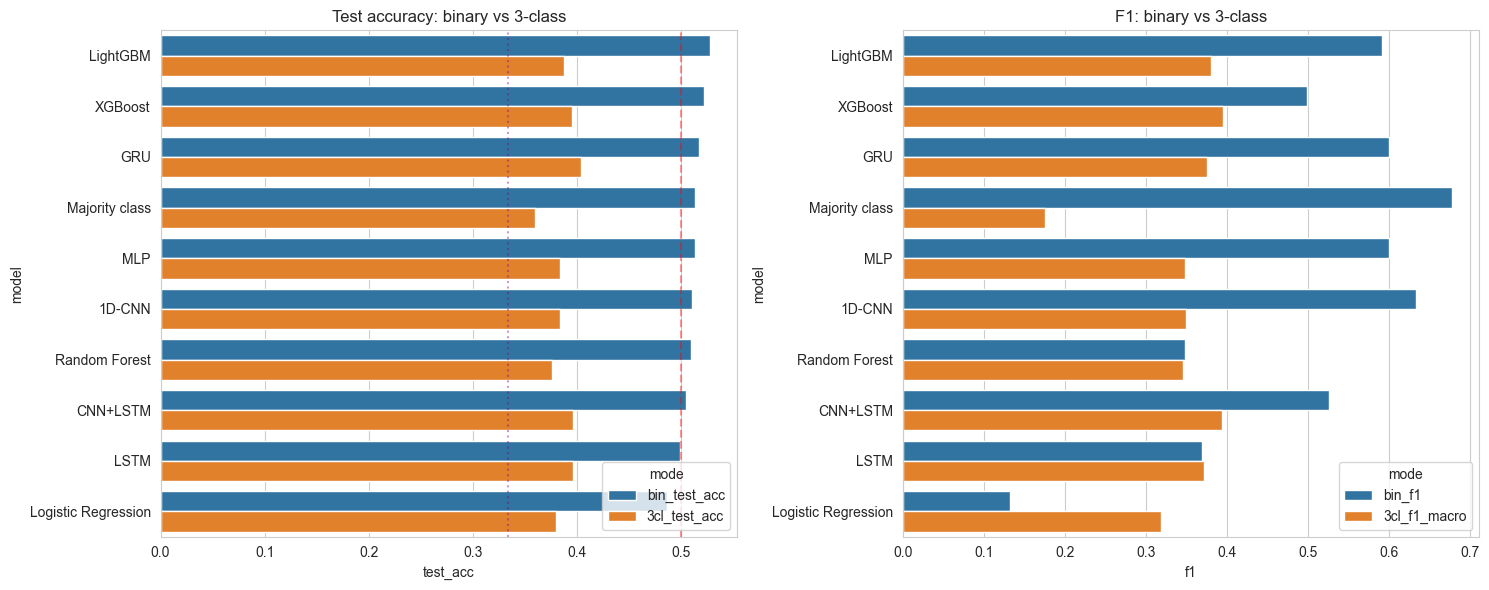

In [23]:
common = sorted(set(results_bin_df["model"]) & set(results_3_df["model"]))
comp = pd.DataFrame({"model": common})
comp["bin_test_acc"] = comp["model"].map(results_bin_df.set_index("model")["test_acc"])
comp["3cl_test_acc"] = comp["model"].map(results_3_df.set_index("model")["test_acc"])
comp["bin_f1"]       = comp["model"].map(results_bin_df.set_index("model")["f1"])
comp["3cl_f1_macro"] = comp["model"].map(results_3_df.set_index("model")["f1_macro"])
comp = comp.sort_values("bin_test_acc", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ma = comp.melt(id_vars="model", value_vars=["bin_test_acc","3cl_test_acc"], var_name="mode", value_name="test_acc")
sns.barplot(data=ma, x="test_acc", y="model", hue="mode", ax=axes[0])
axes[0].axvline(0.5, ls="--", c="red", alpha=0.4); axes[0].axvline(1/3, ls=":", c="purple", alpha=0.4)
axes[0].set_title("Test accuracy: binary vs 3-class")
mf = comp.melt(id_vars="model", value_vars=["bin_f1","3cl_f1_macro"], var_name="mode", value_name="f1")
sns.barplot(data=mf, x="f1", y="model", hue="mode", ax=axes[1]); axes[1].set_title("F1: binary vs 3-class")
plt.tight_layout(); plt.savefig(ARTIFACTS / "binary_vs_3class.png", dpi=120, bbox_inches="tight"); plt.show()

## 18. Bewaar beste model per StockType

Voor elke `StockType` (EQUITY, INDEX, ETF, ...) wordt het binary model met de
hoogste gemiddelde test accuracy gerangschikt en opgeslagen in
`models/<stock_type>/`. Bestaande modellen worden alleen overschreven als het
nieuwe model strict beter scoort (volgens `best.json` metadata).

In [ ]:
import importlib.util
_spec = importlib.util.spec_from_file_location(
    "save_best_models",
    str(PROJECT_ROOT / "model" / "comparison" / "save_best_models.py")
)
sbm = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(sbm)

MODELS_DIR = PROJECT_ROOT / "models"
print(f"trained_models: {len(trained_models)} modellen verzameld")
print(f"  -> {list(trained_models.keys())}")

saved = sbm.save_best_per_type(
    predictions=predictions_bin,         # we slaan binary versie op (productie use case)
    trained_models=trained_models,
    market_df=market_df,
    models_dir=MODELS_DIR,
    notebook_version="V3-binary",
)
print(f"\nTotaal opgeslagen of behouden: {len(saved)} stock types")
print(f"Folder: {MODELS_DIR}")

trained_models: 10 modellen verzameld
  -> ['Majority class', 'Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP', '1D-CNN', 'GRU', 'LSTM', 'CNN+LSTM']

=== Save best model per StockType (V3-binary) ===
  [         EQUITY] SAVED  LightGBM                       acc=0.525  ->  LightGBM.joblib
  [            ETF] SAVED  LightGBM                       acc=0.537  ->  LightGBM.joblib
  [          INDEX] SAVED  GRU                            acc=0.539  ->  GRU.pt

Ranking weggeschreven: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\models\_ranking_V3-binary.csv
Stock types opgeslagen of behouden: 3

Totaal opgeslagen of behouden: 3 stock types
Folder: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\models


: 

## 19. Conclusie

V3 combineert vier dingen die V1/V2 niet hadden:

1. **LLM-based tweet -> stock impact scoring** koppelt elke tweet aan elke stock
   met een impact-score in [0,1]. Sentence-transformer met TF-IDF fallback.
2. **Stock-aware sentiment aggregatie**: tweet-sentiment wordt per stock
   gewogen met de impact-score ipv market-wide.
3. **isPresident feature + presidential boost**: tweets tijdens Trump's
   ambtstermijnen (20 jan 2017 - 20 jan 2021 en vanaf 20 jan 2025) krijgen
   2x meer gewicht in de aggregatie, en de datum-kolom `isPresident` is een
   extra feature voor alle modellen.
4. **Binary vs 3-class vergelijking** met alle 10 modellen in beide modes.

**Beste model per StockType** wordt aan het eind opgeslagen in
`models/<type>/` zodat je het direct kan laden voor inferentie. Cross-version
vergelijking: als V2 of V4 later een hoger scorend model produceert voor
dezelfde stock type, wordt het automatisch vervangen (via `best.json` check).